# Visualización de Embeddings GNN: t-SNE y UMAP

Comparación visual de los embeddings aprendidos en cada Caso del enfoque por partes.
Se usa t-SNE y UMAP para proyectar los embeddings a 2D, coloreados por:
- Relación AS dominante del nodo (P2P / C2P / P2C)
- Grado de salida (log-normalizado)
- PageRank normalizado

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import os
from pathlib import Path
import sys

# Asegurar que el root del repo esté en sys.path para importar modules/
repo_root = Path.cwd().resolve()
if not (repo_root / 'modules').exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from modules.gnn import GNN
import torch
from collections import Counter

# Intentar importar UMAP, si no está, usamos solo t-SNE
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False

def reduce_tsne(emb, seed=42):
    # Normalizamos para que t-SNE no se pierda en escalas distintas
    emb_s = StandardScaler().fit_transform(emb)
    
    # CORRECCIÓN: Usamos 'max_iter' en lugar de 'n_iter' para sklearn moderno
    tsne = TSNE(
        n_components=2, 
        perplexity=30, 
        max_iter=1000, 
        random_state=seed, 
        init='pca',
        learning_rate='auto'
    )
    return tsne.fit_transform(emb_s)

def visualize_case_embeddings(emb_tensor, labels, title, n_samples=5000):
    """
    Toma un tensor de embeddings de una tarea auxiliar y lo visualiza.
    """
    # 1. Muestreo para no saturar la memoria y el gráfico
    if emb_tensor.shape[0] > n_samples:
        idx = np.random.choice(emb_tensor.shape[0], n_samples, replace=False)
        emb_sub = emb_tensor[idx]
        labels_sub = labels[idx]
    else:
        emb_sub = emb_tensor
        labels_sub = labels

    print(f'Calculando t-SNE para {title}...')
    proj = reduce_tsne(emb_sub)

    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        x=proj[:, 0], y=proj[:, 1], 
        hue=labels_sub, 
        palette='viridis', 
        alpha=0.6, 
        edgecolor=None,
        s=15
    )
    plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()
    
    return proj

2026-04-27 17:53:16.046696: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-27 17:53:16.167963: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-27 17:53:16.216671: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-27 17:53:16.232352: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-27 17:53:16.321020: I tensorflow/core/platform/cpu_feature_guar

In [24]:
DATA_PATH = '/media/vale/KINGSTON/TESIS/data_2026/'
RESULTS_PATH = DATA_PATH + 'results/EnfoquePorPartes/'
VIZ_PATH = DATA_PATH + 'results/viz_embeddings/'
os.makedirs(VIZ_PATH, exist_ok=True)

data_path = Path('/media/vale/KINGSTON/TESIS/data_2026')
nodes_file = data_path / 'nodes_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv'
edges_file = data_path / 'edges_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv'

RANDOM_STATE = 42
TSNE_PERPLEXITY = 30
TSNE_ITER = 1000
MAX_NODES = 5000   # subsample para rapidez; None = todos


## Carga del Grafo y Etiquetas de Nodos

In [25]:
gnn = GNN(debug=True)
gnn.load_dataset(str(nodes_file), str(edges_file))
g = gnn.dgl_graph

num_nodes = g.num_nodes()
print(f'Nodos: {num_nodes:,}  Aristas: {g.num_edges():,}')
print(f'Edge data keys: {list(g.edata.keys())}')
print(f'Node data keys: {list(g.ndata.keys())}')


Grafo cargado: 79504 nodos, 734381 aristas
Dimensión de entrada (in_feats): 72
Nodos: 79,504  Aristas: 734,381
Edge data keys: ['label']
Node data keys: ['feat']


In [26]:
# --- Grado de salida (log-normalizado) ---
out_deg = g.out_degrees().float()
out_deg_log = torch.log1p(out_deg)
out_deg_norm = (out_deg_log - out_deg_log.min()) / (out_deg_log.max() - out_deg_log.min() + 1e-8)
color_degree = out_deg_norm.numpy()

# --- Relacion AS dominante por nodo (mayoria de aristas de salida) ---
CLASS_NAMES = {0: 'P2P', 1: 'C2P', 2: 'P2C'}
CLASS_COLORS = {0: '#1f77b4', 1: '#ff7f0e', 2: '#2ca02c'}  # azul, naranja, verde

color_rel = np.full(num_nodes, -1, dtype=int)   # -1 = sin aristas

if 'label' in g.edata:
    src, dst = g.edges()
    labels_e = g.edata['label'].numpy()
    node_votes = [[] for _ in range(num_nodes)]
    for s, lbl in zip(src.numpy(), labels_e):
        if lbl >= 0:
            node_votes[s].append(int(lbl))
    for n in range(num_nodes):
        if node_votes[n]:
            color_rel[n] = Counter(node_votes[n]).most_common(1)[0][0]
    print('Distribución de relacion dominante por nodo:')
    print({CLASS_NAMES.get(k, 'sin_lbl'): v
           for k, v in sorted(Counter(color_rel.tolist()).items())})
else:
    print('No se encontró edata["label"]. Se coloreará solo por grado.')

# --- PageRank (si ya fue calculado y guardado en ndata) ---
if 'pagerank' in g.ndata:
    pr = g.ndata['pagerank'].squeeze().numpy()
    pr_norm = (pr - pr.min()) / (pr.max() - pr.min() + 1e-12)
    color_pagerank = pr_norm
else:
    color_pagerank = None
    print('PageRank no disponible en ndata; se omitirá esa coloración.')


Distribución de relacion dominante por nodo:
{'sin_lbl': 583, 'P2P': 9904, 'C2P': 64835, 'P2C': 4182}
PageRank no disponible en ndata; se omitirá esa coloración.


In [27]:
def subsample(emb, *arrays, max_n=MAX_NODES, seed=RANDOM_STATE):
    """Submuestrea emb y los arrays alineados. Devuelve (idx, emb_sub, *arrays_sub)."""
    n = len(emb)
    if max_n is None or n <= max_n:
        idx = np.arange(n)
    else:
        rng = np.random.default_rng(seed)
        idx = rng.choice(n, max_n, replace=False)
    return (idx, emb[idx]) + tuple(a[idx] for a in arrays)


# def reduce_tsne(emb, seed=RANDOM_STATE):
#     emb_s = StandardScaler().fit_transform(emb)
#     tsne = TSNE(n_components=2, perplexity=TSNE_PERPLEXITY, n_iter=TSNE_ITER,
#                 random_state=seed, init='pca')
#     return tsne.fit_transform(emb_s)
def reduce_tsne(emb, seed=RANDOM_STATE):
    emb_s = StandardScaler().fit_transform(emb)
    # Cambiamos n_iter por max_iter
    tsne = TSNE(n_components=2, 
                perplexity=TSNE_PERPLEXITY, 
                max_iter=TSNE_ITER, # <--- Cambio aquí
                random_state=seed, 
                init='pca')
    return tsne.fit_transform(emb_s)


def reduce_umap(emb, seed=RANDOM_STATE, n_neighbors=15, min_dist=0.1):
    if not UMAP_AVAILABLE:
        return None
    emb_s = StandardScaler().fit_transform(emb)
    reducer = umap.UMAP(n_components=2, n_neighbors=n_neighbors,
                        min_dist=min_dist, random_state=seed)
    return reducer.fit_transform(emb_s)


def scatter_2d(ax, proj, color_vals, title, cmap='viridis',
               alpha=0.5, s=6, colorbar_label=''):
    """Scatter plot continuo."""
    sc = ax.scatter(proj[:, 0], proj[:, 1], c=color_vals,
                    cmap=cmap, alpha=alpha, s=s, linewidths=0)
    plt.colorbar(sc, ax=ax, label=colorbar_label, fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])


def scatter_categorical(ax, proj, labels_int, class_names, class_colors, title,
                         alpha=0.5, s=6):
    """Scatter plot categórico (una serie por clase)."""
    for cls_id, cls_name in class_names.items():
        mask = labels_int == cls_id
        if mask.any():
            ax.scatter(proj[mask, 0], proj[mask, 1],
                       c=class_colors[cls_id], label=cls_name,
                       alpha=alpha, s=s, linewidths=0)
    ax.set_title(title, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(markerscale=3, fontsize=8, loc='best')


def visualize_embeddings(emb_tensor, caso_label, save_prefix,
                          n_neighbors_umap=15):
    """
    Genera una figura con hasta 6 subplots:
      Fila 1 – t-SNE: [relación AS] [grado] [pagerank?]
      Fila 2 – UMAP:  [relación AS] [grado] [pagerank?]
    """
    emb = emb_tensor.detach().cpu().numpy() if torch.is_tensor(emb_tensor) else emb_tensor

    n_cols = 3 if color_pagerank is not None else 2
    n_rows = 2 if UMAP_AVAILABLE else 1

    idx, emb_sub, rel_sub, deg_sub = subsample(
        emb, color_rel, color_degree)
    pr_sub = color_pagerank[idx] if color_pagerank is not None else None

    print(f'Calculando t-SNE para {caso_label} ({len(idx)} nodos)...')
    proj_tsne = reduce_tsne(emb_sub)

    proj_umap = None
    if UMAP_AVAILABLE:
        print(f'Calculando UMAP para {caso_label}...')
        proj_umap = reduce_umap(emb_sub, n_neighbors=n_neighbors_umap)

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(5 * n_cols, 4.5 * n_rows))
    if n_rows == 1:
        axes = axes[np.newaxis, :]   # uniformizar a 2D

    # --- Fila t-SNE ---
    scatter_categorical(axes[0, 0], proj_tsne, rel_sub,
                        CLASS_NAMES, CLASS_COLORS,
                        f't-SNE — Relación AS\n{caso_label}')
    scatter_2d(axes[0, 1], proj_tsne, deg_sub,
               f't-SNE — Grado (log-norm)\n{caso_label}',
               cmap='YlOrRd', colorbar_label='Grado')
    if n_cols == 3:
        scatter_2d(axes[0, 2], proj_tsne, pr_sub,
                   f't-SNE — PageRank\n{caso_label}',
                   cmap='plasma', colorbar_label='PageRank')

    # --- Fila UMAP ---
    if proj_umap is not None:
        scatter_categorical(axes[1, 0], proj_umap, rel_sub,
                            CLASS_NAMES, CLASS_COLORS,
                            f'UMAP — Relación AS\n{caso_label}')
        scatter_2d(axes[1, 1], proj_umap, deg_sub,
                   f'UMAP — Grado (log-norm)\n{caso_label}',
                   cmap='YlOrRd', colorbar_label='Grado')
        if n_cols == 3:
            scatter_2d(axes[1, 2], proj_umap, pr_sub,
                       f'UMAP — PageRank\n{caso_label}',
                       cmap='plasma', colorbar_label='PageRank')

    plt.suptitle(f'Visualización de Embeddings – {caso_label}',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    save_path = VIZ_PATH + f'{save_prefix}.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f'Guardado: {save_path}')
    plt.show()
    return proj_tsne, proj_umap, idx


## Caso 0 – Atributos PeeringDB (mis_attr_marzo)

In [28]:
# Cargar todos los embeddings disponibles del Caso 0
caso0_dir = Path(RESULTS_PATH + 'Caso0')
caso0_files = sorted(caso0_dir.glob('embeddings_ribs_*.pt'))
print('Archivos encontrados:')
for f in caso0_files:
    print(f'  {f.name}')


Archivos encontrados:
  embeddings_ribs_DotProduct_GAT_mis_attr_marzo.pt
  embeddings_ribs_DotProduct_GCN_mis_attr_marzo.pt
  embeddings_ribs_DotProduct_GraphSAGE_mis_attr_marzo.pt
  embeddings_ribs_MLP_GAT_mis_attr_marzo.pt
  embeddings_ribs_MLP_GCN_mis_attr_marzo.pt
  embeddings_ribs_MLP_GraphSAGE_mis_attr_marzo.pt


Shape: torch.Size([79504, 32])
Calculando t-SNE para Caso0 – DotProduct – GCN (5000 nodos)...
Calculando UMAP para Caso0 – DotProduct – GCN...


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Guardado: /media/vale/KINGSTON/TESIS/data_2026/results/viz_embeddings/caso0_dotproduct_gcn.png


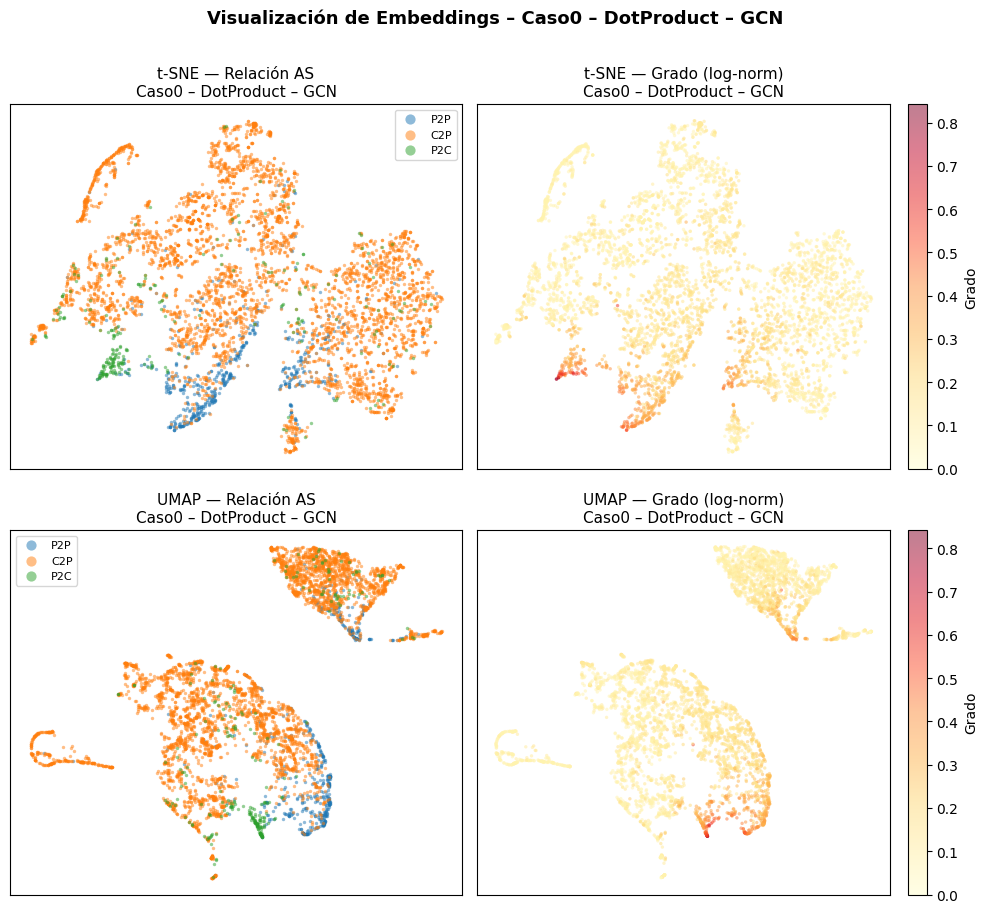

In [29]:
# --- DotProduct – GCN ---
emb_c0_dp_gcn = torch.load(RESULTS_PATH + 'Caso0/embeddings_ribs_DotProduct_GCN_mis_attr_marzo.pt',
                            map_location='cpu')
print(f'Shape: {emb_c0_dp_gcn.shape}')
proj_tsne_c0, proj_umap_c0, idx_c0 = visualize_embeddings(
    emb_c0_dp_gcn, 'Caso0 – DotProduct – GCN', 'caso0_dotproduct_gcn')


Calculando t-SNE para Caso0 – MLP – GCN (5000 nodos)...
Calculando UMAP para Caso0 – MLP – GCN...


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Guardado: /media/vale/KINGSTON/TESIS/data_2026/results/viz_embeddings/caso0_mlp_gcn.png


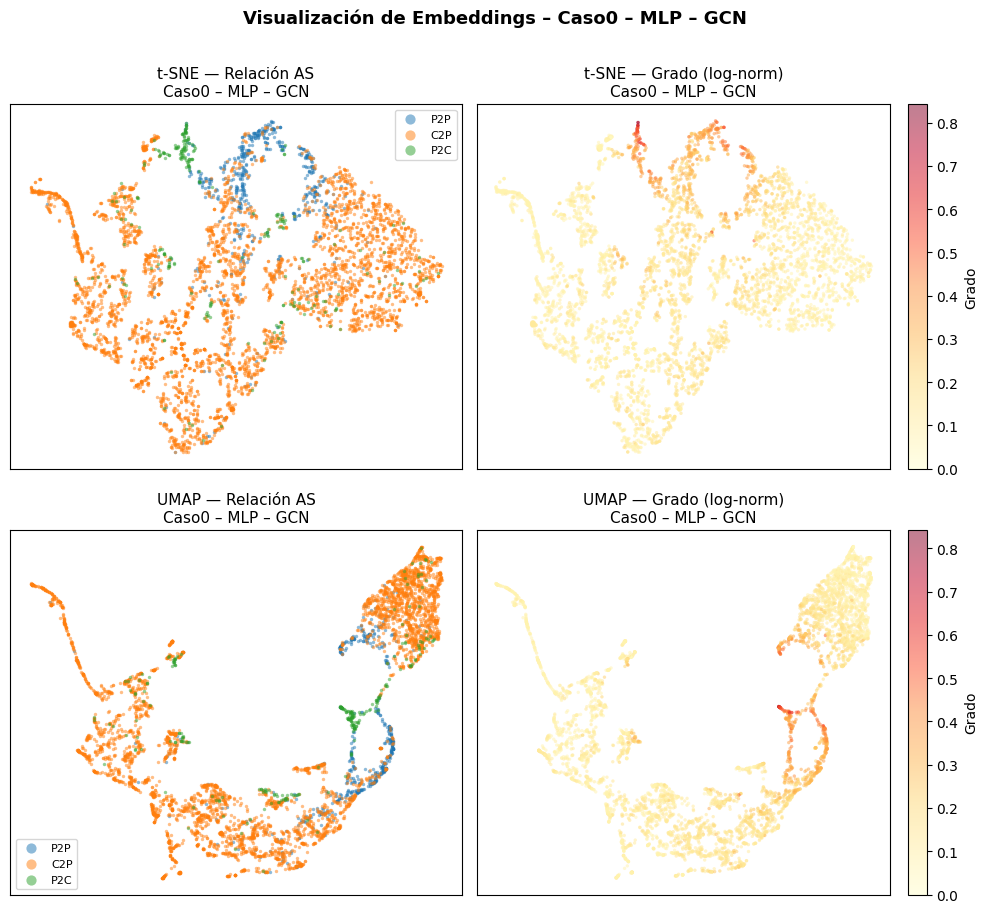

(array([[ 52.409164 , -13.825688 ],
        [ -6.9438844,  22.060875 ],
        [-18.925146 , -26.962023 ],
        ...,
        [-62.6477   , -22.932978 ],
        [-19.233557 , -33.85117  ],
        [ 50.044376 ,  14.483261 ]], dtype=float32),
 array([[14.679117  ,  7.552701  ],
        [10.564208  , -2.9698138 ],
        [ 3.8728395 , -5.3589044 ],
        ...,
        [-1.0113266 , -0.50191486],
        [ 3.831948  , -4.432812  ],
        [13.404404  ,  8.270676  ]], dtype=float32),
 array([37148, 50554, 61054, ..., 52039, 61531,  7095]))

In [30]:
# --- MLP – GCN ---
emb_c0_mlp_gcn = torch.load(RESULTS_PATH + 'Caso0/embeddings_ribs_MLP_GCN_mis_attr_marzo.pt',
                             map_location='cpu')
visualize_embeddings(emb_c0_mlp_gcn, 'Caso0 – MLP – GCN', 'caso0_mlp_gcn')


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


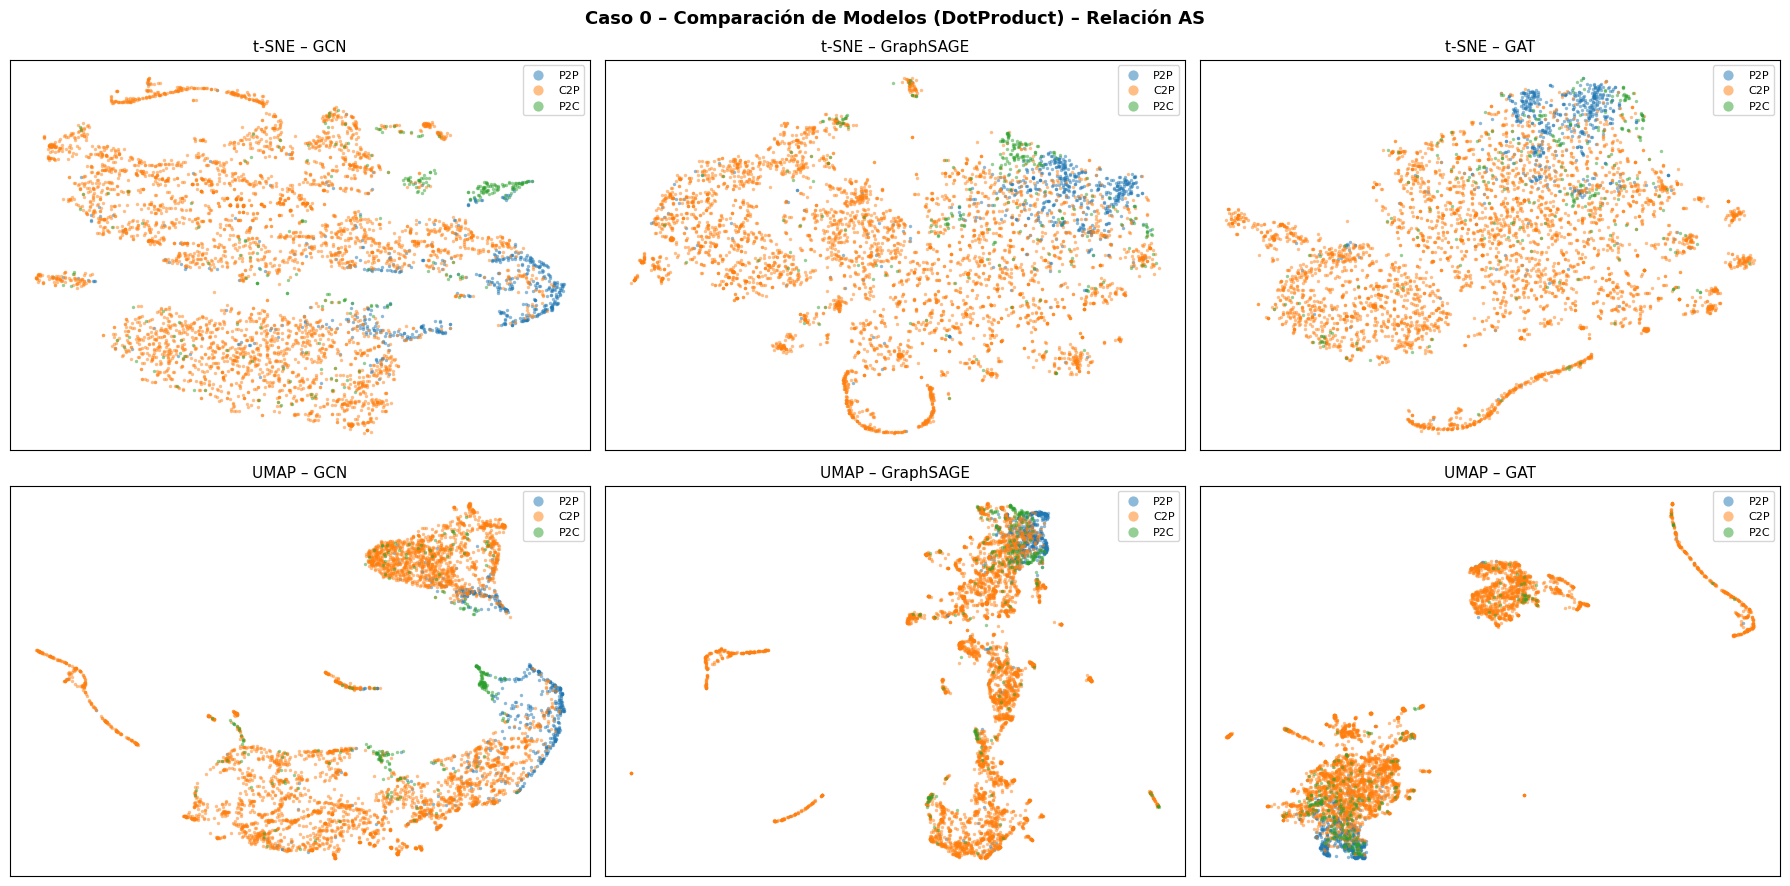

In [15]:
# Comparación de los tres modelos con DotProduct (lado a lado)
model_names = ['GCN', 'GraphSAGE', 'GAT']
embs_c0 = {}
for mn in model_names:
    path = RESULTS_PATH + f'Caso0/embeddings_ribs_DotProduct_{mn}_mis_attr_marzo.pt'
    if Path(path).exists():
        embs_c0[mn] = torch.load(path, map_location='cpu').detach().numpy()

fig, axes = plt.subplots(2, len(embs_c0), figsize=(6 * len(embs_c0), 9))
if len(embs_c0) == 1:
    axes = axes[:, np.newaxis]

for col, (mn, emb) in enumerate(embs_c0.items()):
    idx, emb_sub, rel_sub, deg_sub = subsample(emb, color_rel, color_degree)
    proj_t = reduce_tsne(emb_sub)
    proj_u = reduce_umap(emb_sub) if UMAP_AVAILABLE else None
    scatter_categorical(axes[0, col], proj_t, rel_sub,
                        CLASS_NAMES, CLASS_COLORS,
                        f't-SNE – {mn}')
    if proj_u is not None:
        scatter_categorical(axes[1, col], proj_u, rel_sub,
                            CLASS_NAMES, CLASS_COLORS,
                            f'UMAP – {mn}')
    else:
        axes[1, col].axis('off')

plt.suptitle('Caso 0 – Comparación de Modelos (DotProduct) – Relación AS',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(VIZ_PATH + 'caso0_comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()


## Caso 3 – Predicción de Grado de Salida

In [31]:
caso3_dir = Path(RESULTS_PATH + 'Caso3')
print('Archivos encontrados:')
for f in sorted(caso3_dir.glob('embeddings_*.pt')):
    print(f'  {f.name}')


Archivos encontrados:
  embeddings_ribs_GAT_out_degree.pt
  embeddings_ribs_GCN_out_degree.pt
  embeddings_ribs_GraphSAGE_out_degree.pt



--- GCN --- shape=torch.Size([79504, 32])
Calculando t-SNE para Caso3 – GCN (5000 nodos)...


Calculando UMAP para Caso3 – GCN...


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Guardado: /media/vale/KINGSTON/TESIS/data_2026/results/viz_embeddings/caso3_gcn.png


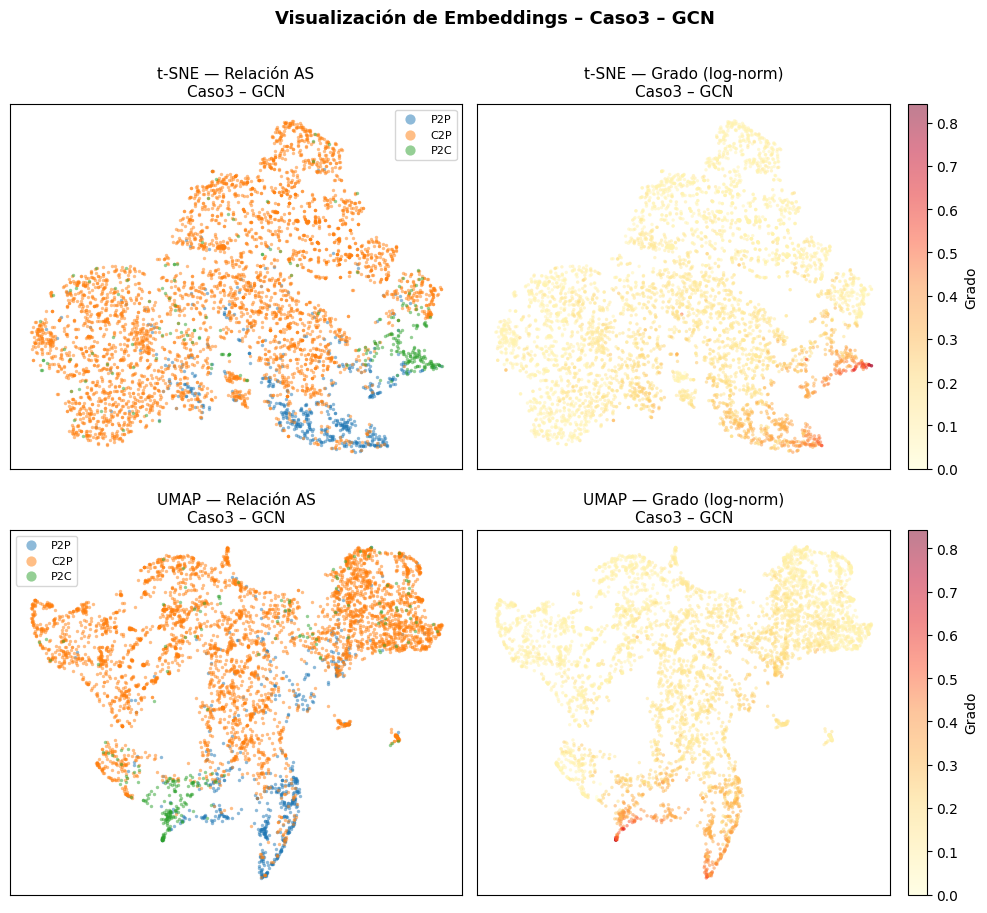


--- GraphSAGE --- shape=torch.Size([79504, 32])
Calculando t-SNE para Caso3 – GraphSAGE (5000 nodos)...
Calculando UMAP para Caso3 – GraphSAGE...


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Guardado: /media/vale/KINGSTON/TESIS/data_2026/results/viz_embeddings/caso3_graphsage.png


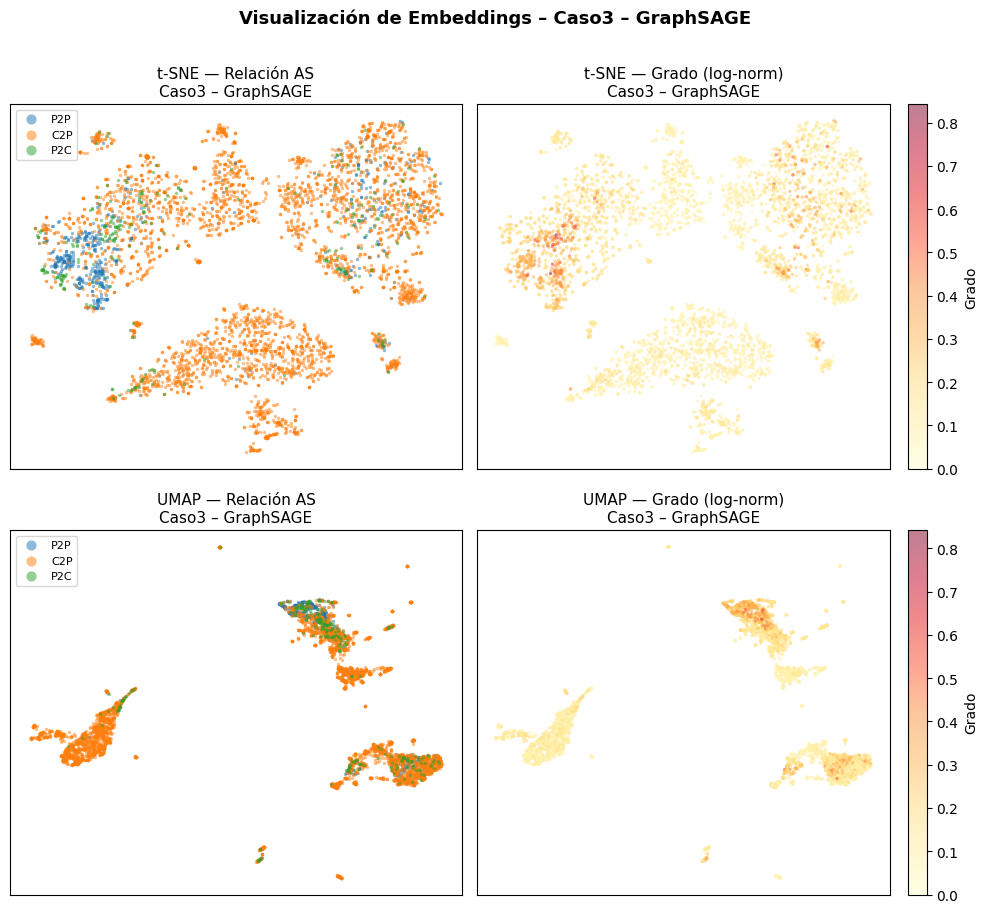


--- GAT --- shape=torch.Size([79504, 32])
Calculando t-SNE para Caso3 – GAT (5000 nodos)...
Calculando UMAP para Caso3 – GAT...


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Guardado: /media/vale/KINGSTON/TESIS/data_2026/results/viz_embeddings/caso3_gat.png


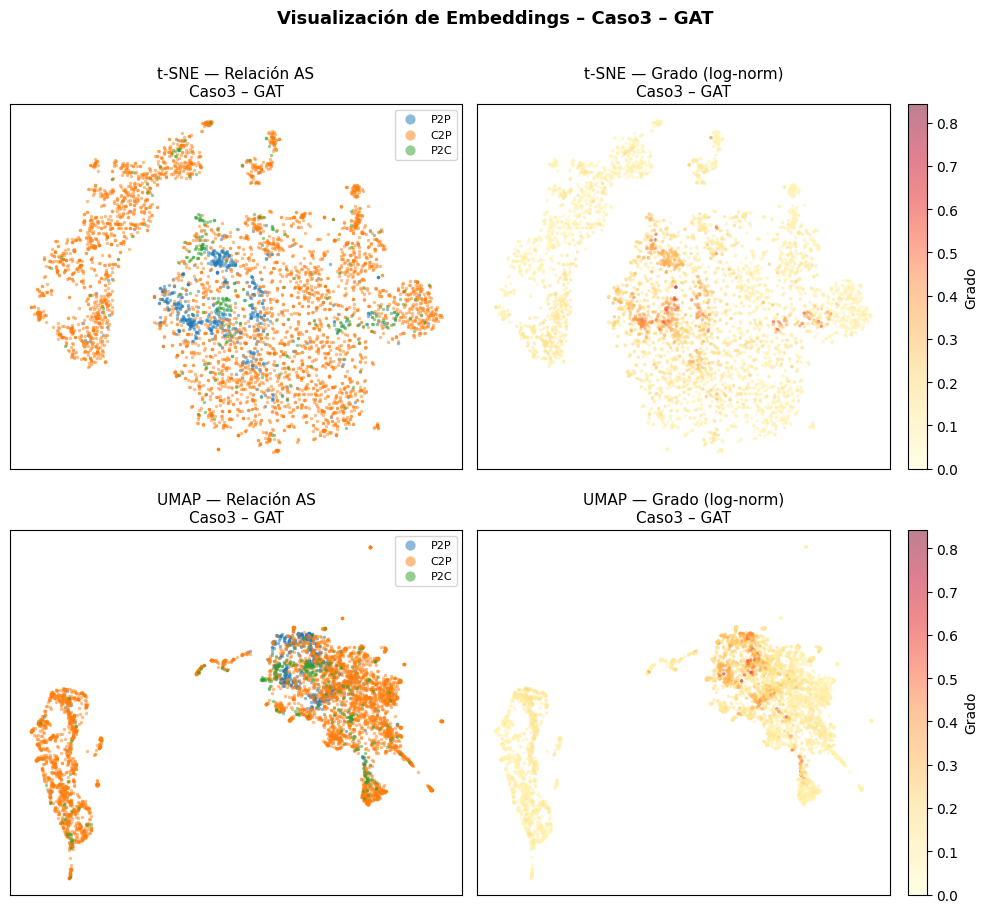

In [32]:
for mn in ['GCN', 'GraphSAGE', 'GAT']:
    # Intentar nuevo nombre primero, luego nombre anterior
    for fname in [f'embeddings_ribs_{mn}_out_degree.pt',
                  f'embeddings_ribs_{mn}_out_degree_febrero.pt']:
        p = RESULTS_PATH + f'Caso3/{fname}'
        if Path(p).exists():
            emb = torch.load(p, map_location='cpu')
            print(f'\n--- {mn} --- shape={emb.shape}')
            visualize_embeddings(emb, f'Caso3 – {mn}', f'caso3_{mn.lower()}')
            break


## Caso 4 – Predicción de PageRank

In [33]:
caso4_dir = Path(RESULTS_PATH + 'Caso4')
print('Archivos encontrados:')
for f in sorted(caso4_dir.glob('embeddings_*.pt')):
    print(f'  {f.name}')


Archivos encontrados:
  embeddings_mlp_GAT_pagerank_norm.pt
  embeddings_mlp_GCN_pagerank_norm.pt
  embeddings_mlp_GraphSAGE_pagerank_norm.pt
  embeddings_ribs_GAT_pagerank_norm.pt
  embeddings_ribs_GCN_pagerank_norm.pt
  embeddings_ribs_GraphSAGE_pagerank_norm.pt



--- GCN --- shape=torch.Size([79504, 32])
Calculando t-SNE para Caso4 – Encoder – GCN (5000 nodos)...
Calculando UMAP para Caso4 – Encoder – GCN...


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Guardado: /media/vale/KINGSTON/TESIS/data_2026/results/viz_embeddings/caso4_enc_gcn.png


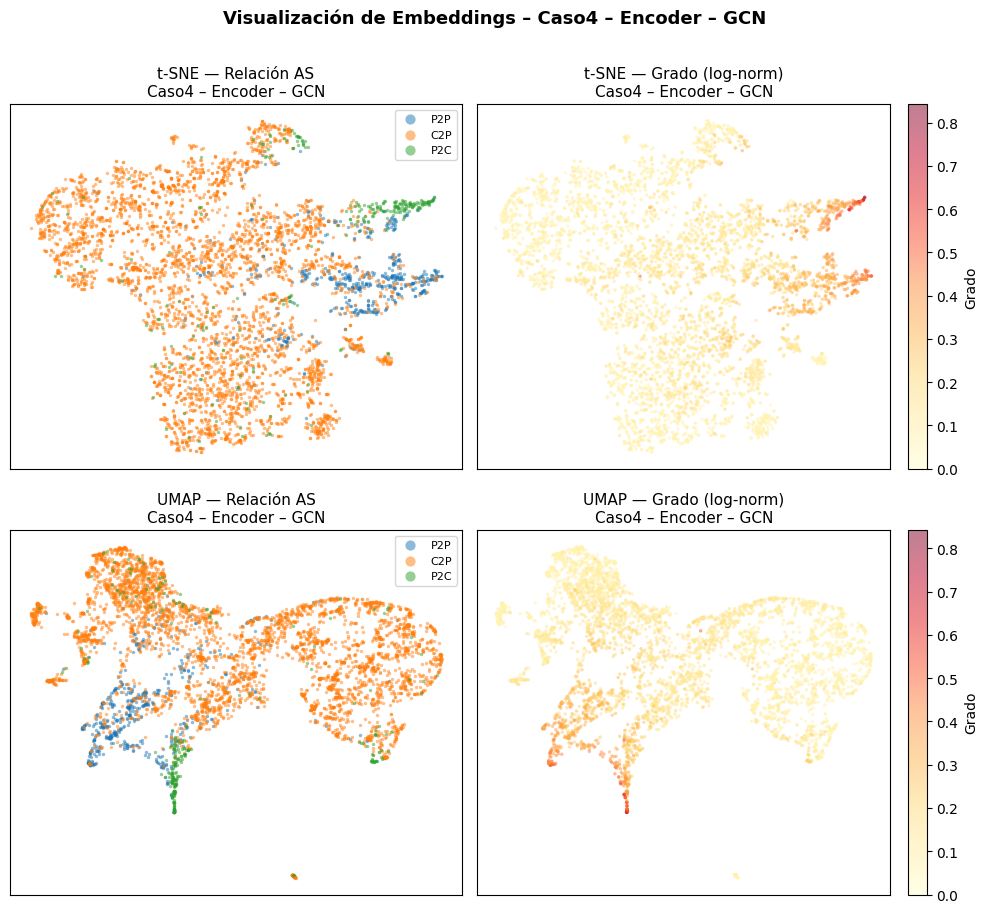


--- GraphSAGE --- shape=torch.Size([79504, 32])
Calculando t-SNE para Caso4 – Encoder – GraphSAGE (5000 nodos)...
Calculando UMAP para Caso4 – Encoder – GraphSAGE...


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Guardado: /media/vale/KINGSTON/TESIS/data_2026/results/viz_embeddings/caso4_enc_graphsage.png


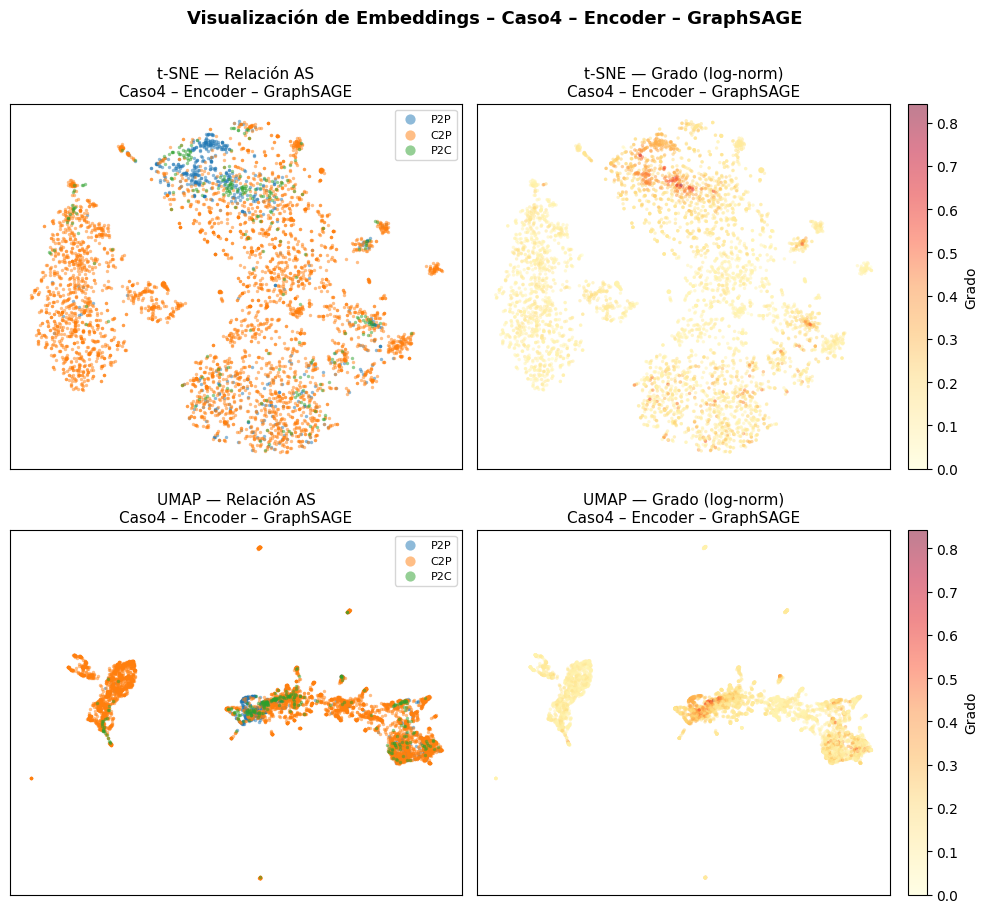


--- GAT --- shape=torch.Size([79504, 32])
Calculando t-SNE para Caso4 – Encoder – GAT (5000 nodos)...
Calculando UMAP para Caso4 – Encoder – GAT...


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Guardado: /media/vale/KINGSTON/TESIS/data_2026/results/viz_embeddings/caso4_enc_gat.png


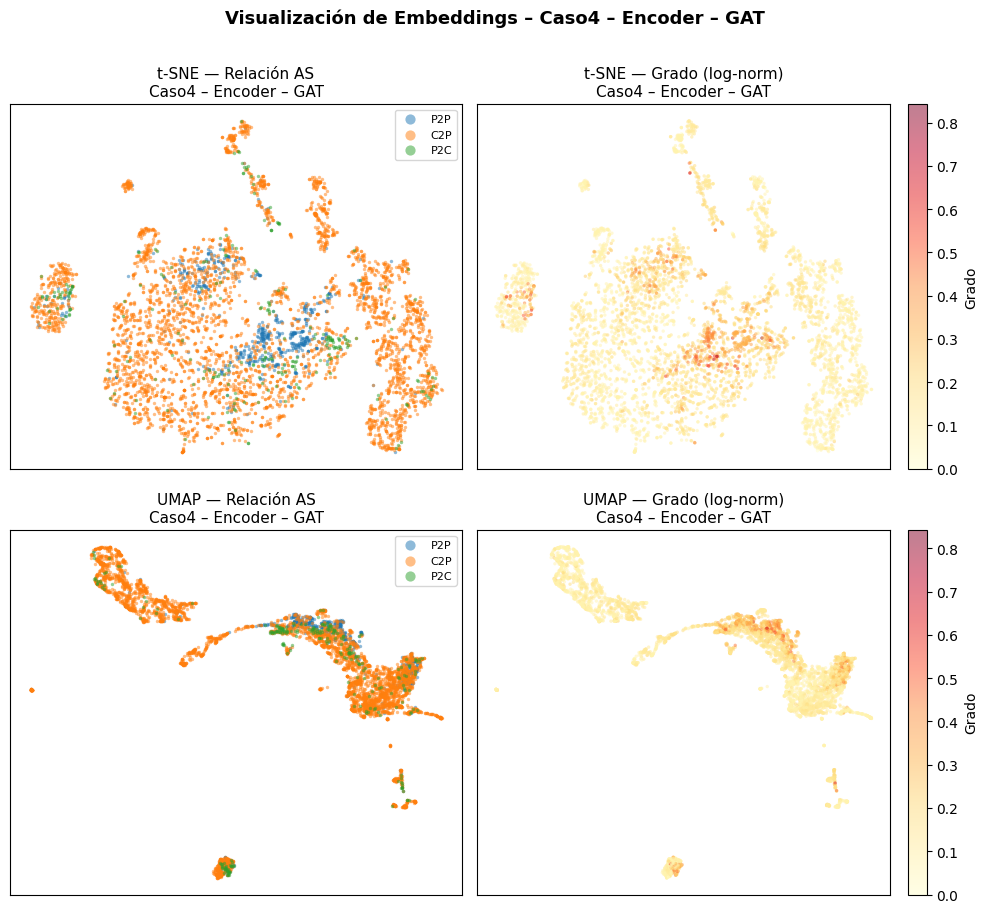

In [34]:
for mn in ['GCN', 'GraphSAGE', 'GAT']:
    for fname in [f'embeddings_ribs_{mn}_pagerank_norm.pt',
                  f'embeddings_ribs_{mn}_pagerank_norm_febrero.pt']:
        p = RESULTS_PATH + f'Caso4/{fname}'
        if Path(p).exists():
            emb = torch.load(p, map_location='cpu')
            print(f'\n--- {mn} --- shape={emb.shape}')
            visualize_embeddings(emb, f'Caso4 – Encoder – {mn}', f'caso4_enc_{mn.lower()}')
            break



--- GCN (MLP) --- shape=torch.Size([79504, 32])
Calculando t-SNE para Caso4 – MLP – GCN (5000 nodos)...
Calculando UMAP para Caso4 – MLP – GCN...


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Guardado: /media/vale/KINGSTON/TESIS/data_2026/results/viz_embeddings/caso4_mlp_gcn.png


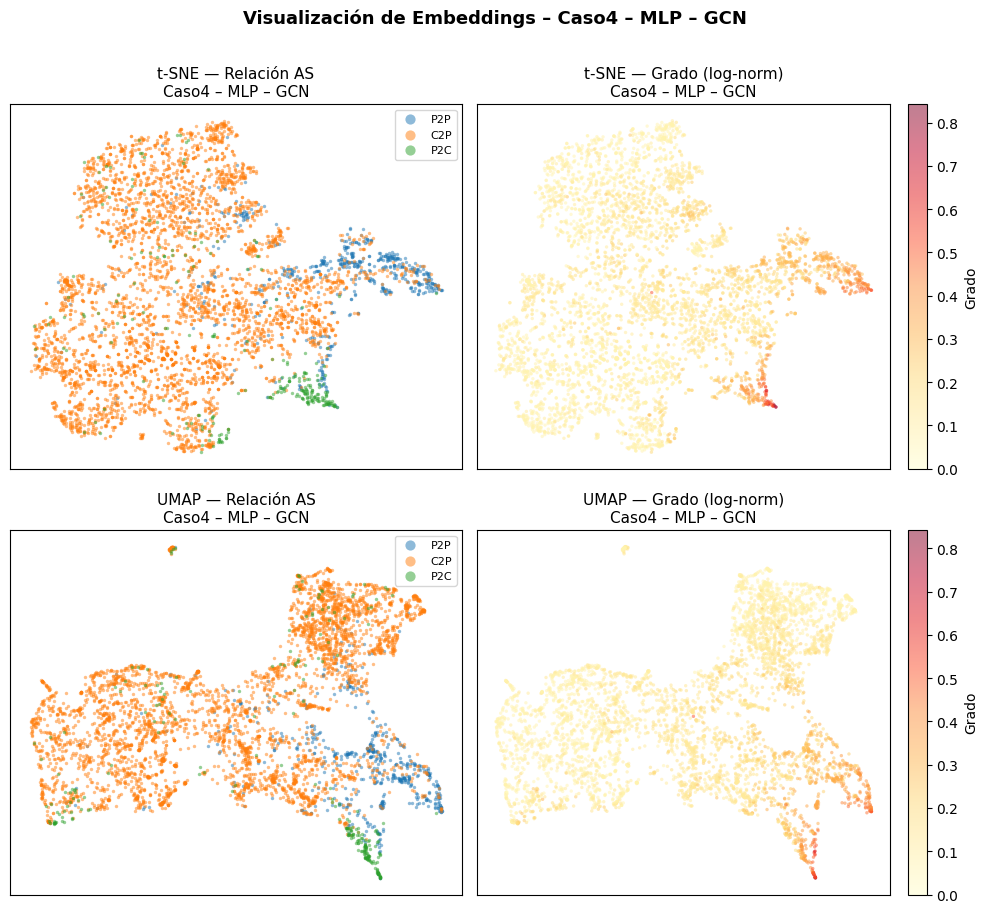


--- GraphSAGE (MLP) --- shape=torch.Size([79504, 32])
Calculando t-SNE para Caso4 – MLP – GraphSAGE (5000 nodos)...
Calculando UMAP para Caso4 – MLP – GraphSAGE...


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Guardado: /media/vale/KINGSTON/TESIS/data_2026/results/viz_embeddings/caso4_mlp_graphsage.png


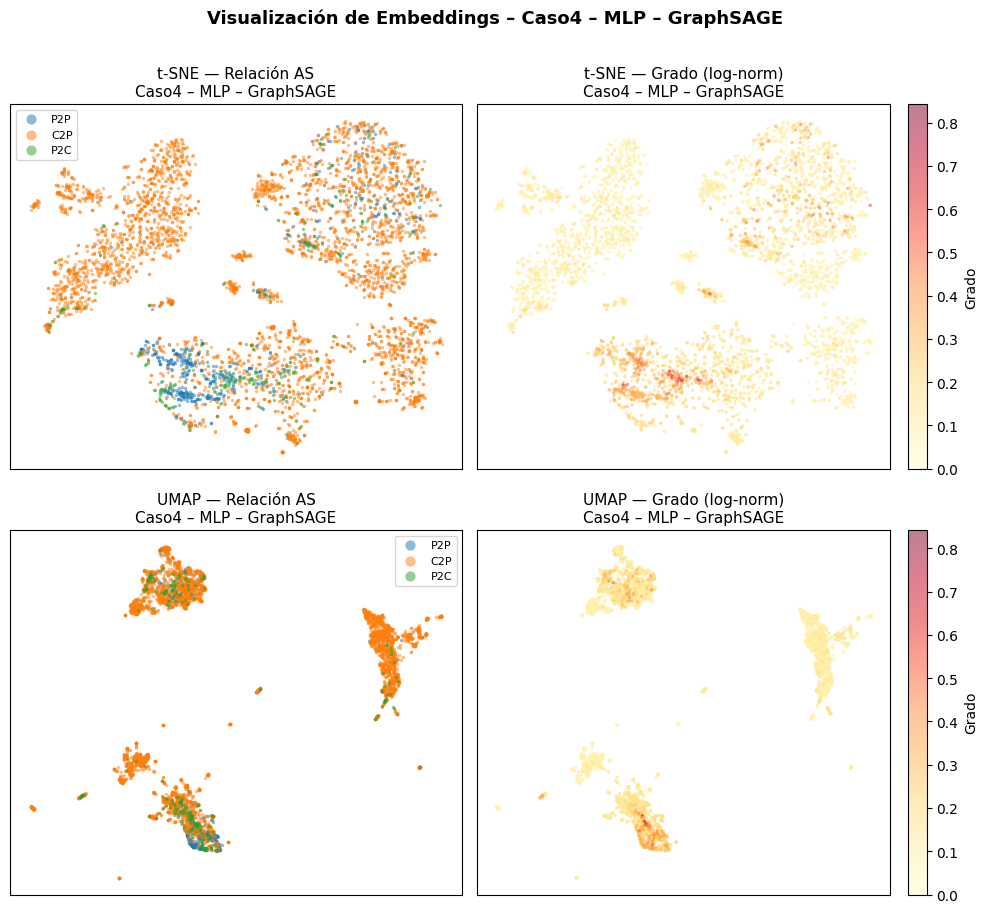


--- GAT (MLP) --- shape=torch.Size([79504, 32])
Calculando t-SNE para Caso4 – MLP – GAT (5000 nodos)...
Calculando UMAP para Caso4 – MLP – GAT...


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Guardado: /media/vale/KINGSTON/TESIS/data_2026/results/viz_embeddings/caso4_mlp_gat.png


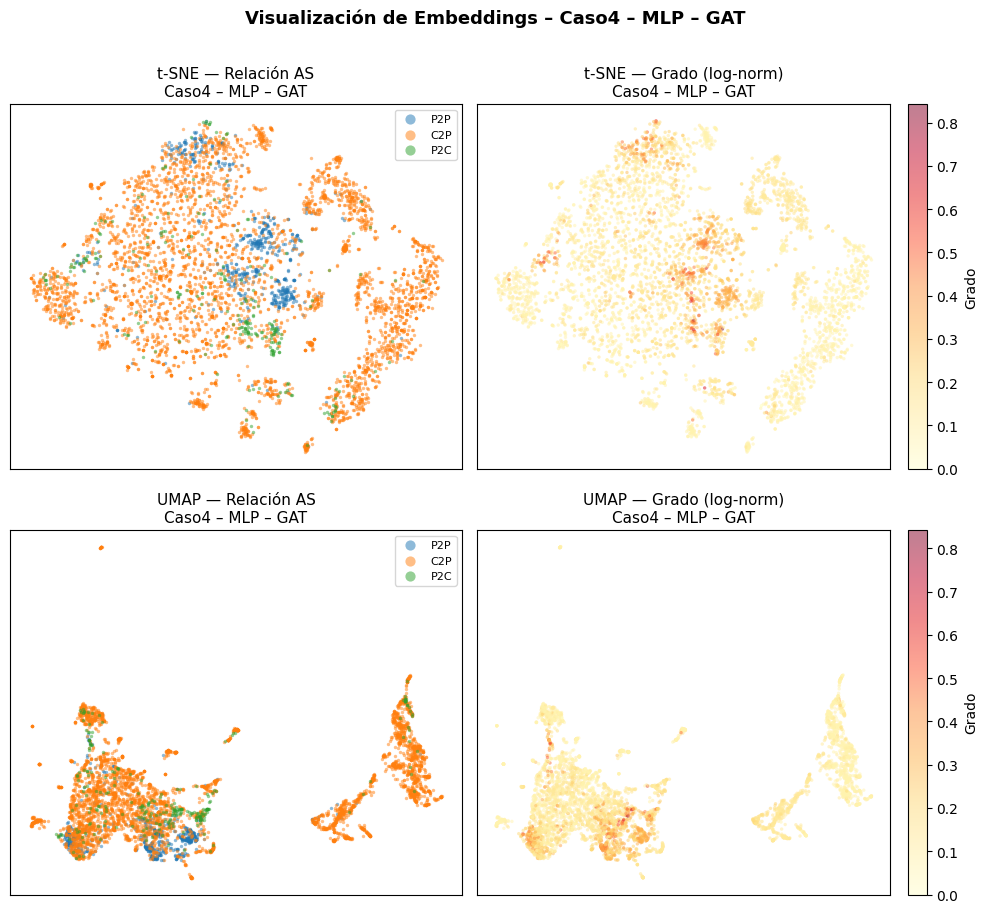

In [36]:
# Versión MLP regressor
for mn in ['GCN', 'GraphSAGE', 'GAT']:
    for fname in [f'embeddings_mlp_{mn}_pagerank_norm.pt',
                  f'embeddings_mlp_{mn}_pagerank_norm_febrero.pt']:
        p = RESULTS_PATH + f'Caso4/{fname}'
        if Path(p).exists():
            emb = torch.load(p, map_location='cpu')
            print(f'\n--- {mn} (MLP) --- shape={emb.shape}')
            visualize_embeddings(emb, f'Caso4 – MLP – {mn}', f'caso4_mlp_{mn.lower()}')
            break


## Caso 5 – DeepWalk

DeepWalk embeddings shape: torch.Size([79504, 32])
Calculando t-SNE para Caso5 – DeepWalk (5000 nodos)...
Calculando UMAP para Caso5 – DeepWalk...


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Guardado: /home/vale/Escritorio/GIT/TrabajoTesis/results/viz_embeddings/caso5_deepwalk.png


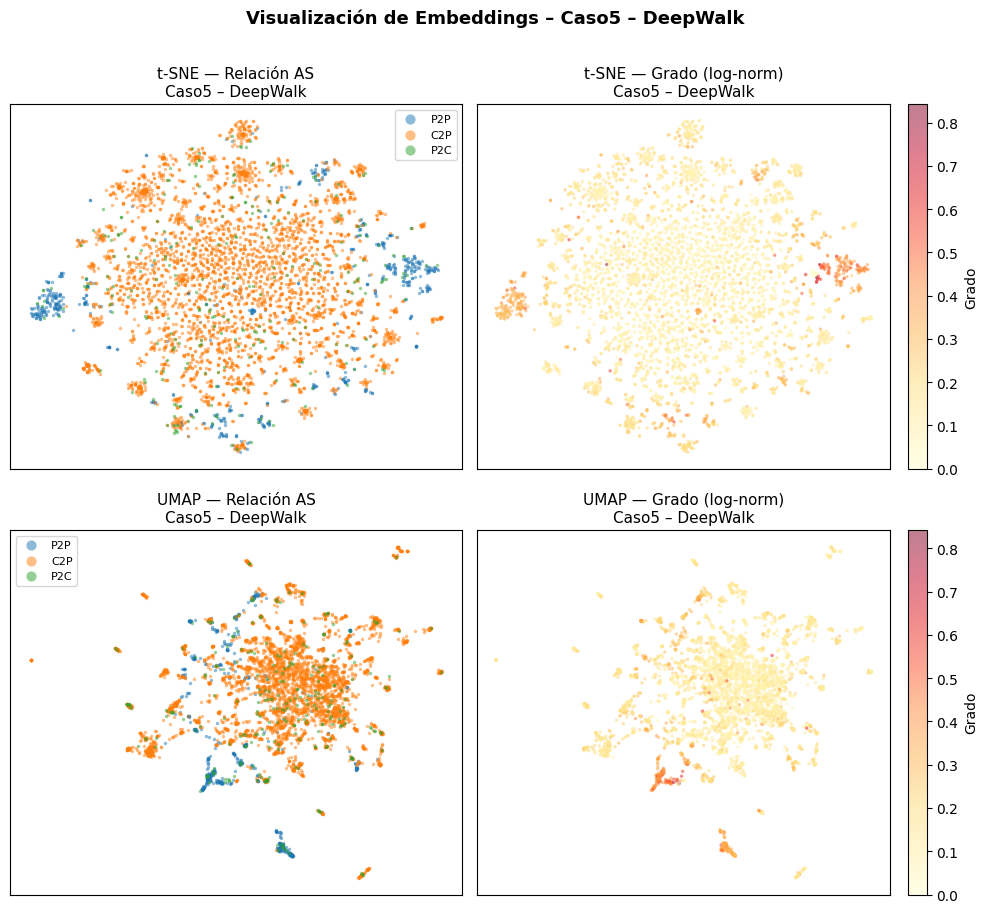

In [21]:
dw_path = RESULTS_PATH + 'Caso5/embeddings_deepWalk_marzo_2026.pt'
if Path(dw_path).exists():
    emb_dw = torch.load(dw_path, map_location='cpu')
    print(f'DeepWalk embeddings shape: {emb_dw.shape}')
    visualize_embeddings(emb_dw, 'Caso5 – DeepWalk', 'caso5_deepwalk')
else:
    print(f'Archivo no encontrado: {dw_path}')


## Comparación entre todos los Casos (GCN)

Casos disponibles: ['Caso0\n(DotProduct)', 'Caso3\n(OutDegree)', 'Caso4\n(PageRank)', 'Caso5\n(DeepWalk)']


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


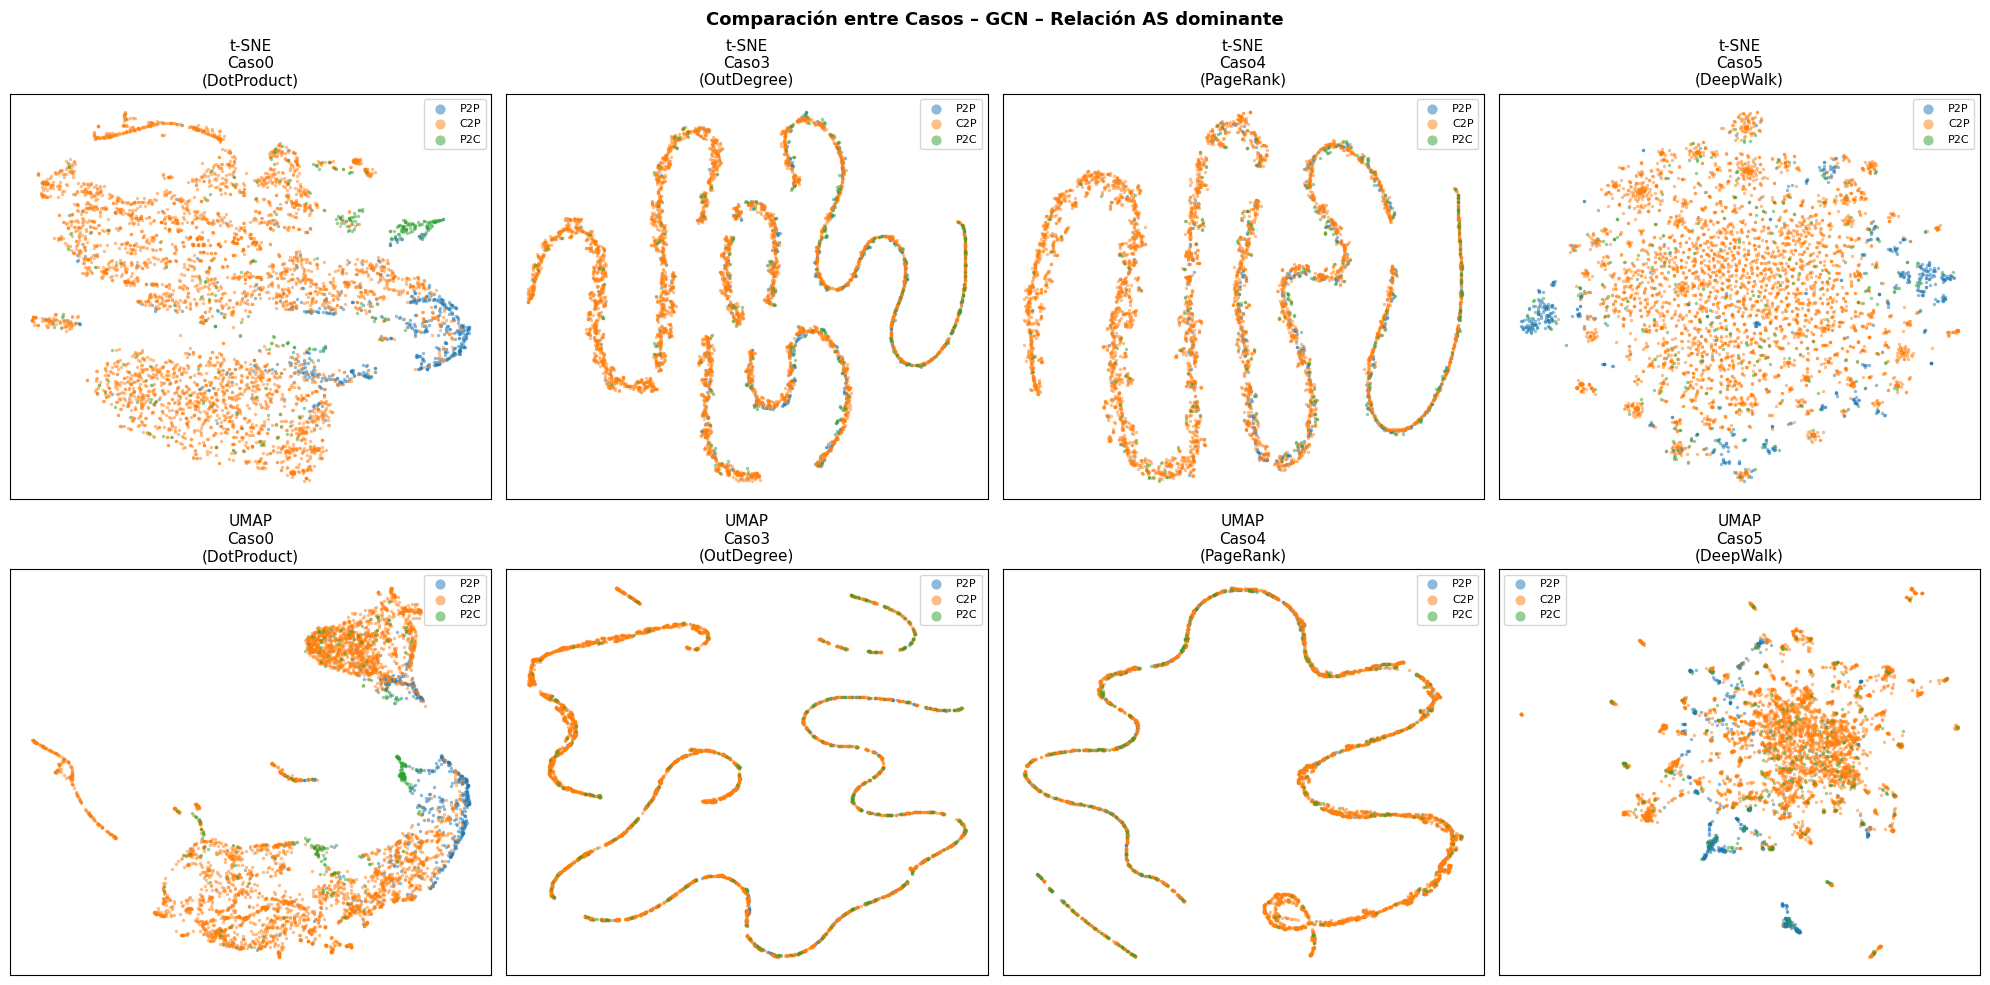

In [ ]:
# Cargar un embedding representativo por caso (GCN)
candidates = {
    'Caso0\n(DotProduct)': RESULTS_PATH + 'Caso0/embeddings_ribs_DotProduct_GCN_mis_attr_marzo.pt',
    'Caso3\n(OutDegree)' : RESULTS_PATH + 'Caso3/embeddings_ribs_GCN_out_degree_marzo.pt',
    'Caso4\n(PageRank)'  : RESULTS_PATH + 'Caso4/embeddings_ribs_GCN_pagerank_norm_marzo.pt',
    'Caso5\n(DeepWalk)'  : RESULTS_PATH + 'Caso5/embeddings_deepWalk_marzo_2026.pt',
}

available = {k: v for k, v in candidates.items() if Path(v).exists()}
print(f'Casos disponibles: {list(available.keys())}')

n_cases = len(available)
fig, axes = plt.subplots(2, n_cases, figsize=(5 * n_cases, 10))
if n_cases == 1:
    axes = axes[:, np.newaxis]

for col, (label, path) in enumerate(available.items()):
    emb = torch.load(path, map_location='cpu').detach().numpy()
    idx, emb_sub, rel_sub, deg_sub = subsample(emb, color_rel, color_degree)
    proj_t = reduce_tsne(emb_sub)
    proj_u = reduce_umap(emb_sub) if UMAP_AVAILABLE else None
    scatter_categorical(axes[0, col], proj_t, rel_sub,
                        CLASS_NAMES, CLASS_COLORS, f't-SNE\n{label}')
    if proj_u is not None:
        scatter_categorical(axes[1, col], proj_u, rel_sub,
                            CLASS_NAMES, CLASS_COLORS, f'UMAP\n{label}')
    else:
        axes[1, col].axis('off')

plt.suptitle('Comparación entre Casos – GCN – Relación AS dominante',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(VIZ_PATH + 'comparacion_casos_gcn.png', dpi=150, bbox_inches='tight')
plt.show()


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


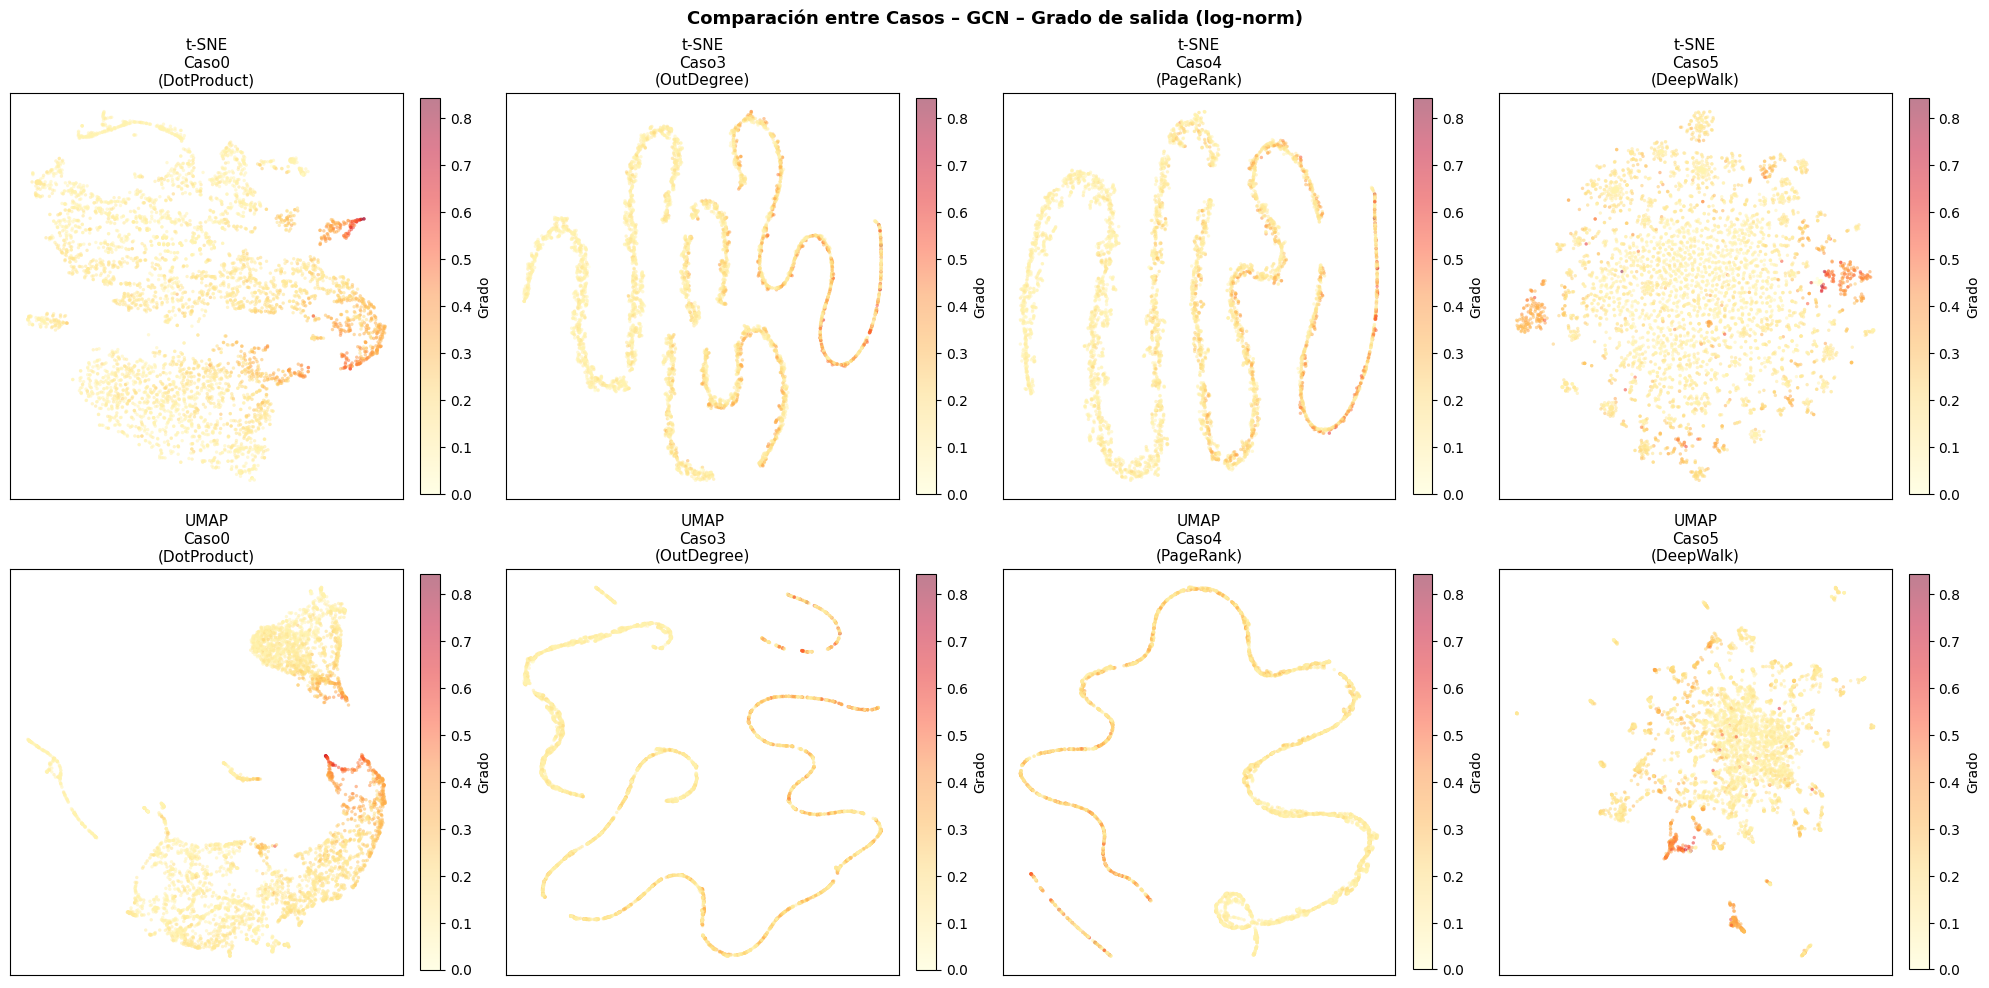

In [23]:
# Misma comparación coloreada por grado
fig, axes = plt.subplots(2, n_cases, figsize=(5 * n_cases, 10))
if n_cases == 1:
    axes = axes[:, np.newaxis]

for col, (label, path) in enumerate(available.items()):
    emb = torch.load(path, map_location='cpu').detach().numpy()
    idx, emb_sub, rel_sub, deg_sub = subsample(emb, color_rel, color_degree)
    proj_t = reduce_tsne(emb_sub)
    proj_u = reduce_umap(emb_sub) if UMAP_AVAILABLE else None
    scatter_2d(axes[0, col], proj_t, deg_sub,
               f't-SNE\n{label}', cmap='YlOrRd', colorbar_label='Grado')
    if proj_u is not None:
        scatter_2d(axes[1, col], proj_u, deg_sub,
                   f'UMAP\n{label}', cmap='YlOrRd', colorbar_label='Grado')
    else:
        axes[1, col].axis('off')

plt.suptitle('Comparación entre Casos – GCN – Grado de salida (log-norm)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(VIZ_PATH + 'comparacion_casos_gcn_grado.png', dpi=150, bbox_inches='tight')
plt.show()


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

def plot_case_comparison(embeddings_list, labels, case_names):
    """
    Compara visualmente los embeddings de los diferentes casos.
    """
    fig, axes = plt.subplots(1, len(embeddings_list), figsize=(20, 5))
    
    for i, emb in enumerate(embeddings_list):
        # Reducción de dimensionalidad
        tsne = TSNE(n_components=2, perplexity=30, random_state=42)
        proj = tsne.fit_transform(emb[:5000]) # Muestreo para rapidez
        
        sns.scatterplot(
            x=proj[:, 0], y=proj[:, 1], 
            hue=labels[:5000], 
            ax=axes[i], palette='viridis', s=10, alpha=0.6
        )
        axes[i].set_title(f'Embeddings: {case_names[i]}')
        axes[i].get_legend().remove()
    
    plt.show()

# Uso sugerido:
plot_case_comparison([emb_c0_mlp_gcn, emb_c1_mlp_gcn, emb_c3_mlp_gcn, emb_c4_mlp_gcn], y_train, ['LinkPred', 'DegPred', 'PRPred', 'Semantics'])

NameError: name 'emb_c1_mlp_gcn' is not defined

. ¿Por qué esto es vital para tu Tesis?

Como tu entrenamiento es por partes, la visualización no es solo estética; es el control de calidad de tu "Feature Engineering" automático.

![Captura desde 2026-04-16 03-04-52.png](<attachment:Captura desde 2026-04-16 03-04-52.png>)
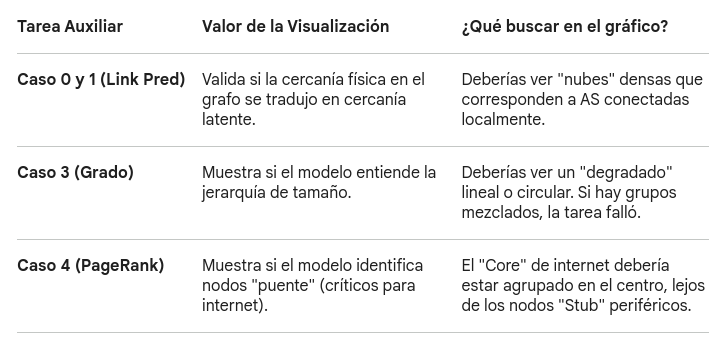

In [30]:
from sklearn.metrics import silhouette_score

def check_embedding_bias(embeddings, classes, degrees, n_samples=3000):
    # Tomamos una muestra para el cálculo
    idx = np.random.choice(len(embeddings), n_samples, replace=False)
    emb_sample = embeddings[idx]
    
    # 1. ¿Qué tanto se agrupan por clase real? (P2P, C2P, P2C)
    score_clase = silhouette_score(emb_sample, classes[idx])
    
    # 2. ¿Qué tanto se agrupan solo por tamaño (grado)?
    # Discretizamos el grado en 5 niveles para comparar
    degree_bins = pd.qcut(degrees[idx], q=5, labels=False, duplicates='drop')
    score_grado = silhouette_score(emb_sample, degree_bins)
    
    print(f"--- Análisis de Separación ---")
    print(f"Cohesión por Clase: {score_clase:.4f}")
    print(f"Cohesión por Grado: {score_grado:.4f}")
    
    if score_clase > score_grado:
        print("RESULTADO: El embedding prioriza la semántica de la relación.")
    else:
        print("RESULTADO: El embedding está sesgado por el tamaño del nodo.")

In [1]:
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

def reduce_tsne(emb, seed=42):
    # Paso 1: Escalar para que dimensiones de 32 no tengan sesgos de magnitud
    emb_s = StandardScaler().fit_transform(emb)
    
    # Paso 2: t-SNE con parámetros actualizados para sklearn 1.7+
    tsne = TSNE(
        n_components=2, 
        perplexity=30, 
        max_iter=1000, # <-- Antes era n_iter
        random_state=seed, 
        init='pca',
        learning_rate='auto'
    )
    return tsne.fit_transform(emb_s)

def visualize_embeddings_thesis(emb_tensor, labels, title, n_samples=5000):
    # Muestreo aleatorio si hay demasiados nodos
    if emb_tensor.shape[0] > n_samples:
        idx = np.random.choice(emb_tensor.shape[0], n_samples, replace=False)
        emb_sub = emb_tensor[idx]
        labels_sub = labels[idx]
    else:
        emb_sub = emb_tensor
        labels_sub = labels

    print(f'Procesando t-SNE para: {title}...')
    proj = reduce_tsne(emb_sub.detach().cpu().numpy())

    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        x=proj[:, 0], y=proj[:, 1], 
        hue=labels_sub, 
        palette='tab10', 
        s=20, alpha=0.7, edgecolor=None
    )
    plt.title(f"Visualización de Embeddings - {title}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
    plt.grid(True, alpha=0.3)
    plt.show()

In [2]:
from sklearn.metrics import silhouette_score
import pandas as pd

def analyze_case_quality(embeddings, classes, degrees, n_samples=2500):
    idx = np.random.choice(len(embeddings), n_samples, replace=False)
    emb_sample = embeddings[idx].detach().cpu().numpy()
    
    # Silueta por la etiqueta que queremos clasificar después
    s_clase = silhouette_score(emb_sample, classes[idx])
    
    # Silueta por grupos de grado (para ver el sesgo topológico)
    degree_bins = pd.qcut(degrees[idx], q=5, labels=False, duplicates='drop')
    s_grado = silhouette_score(emb_sample, degree_bins)
    
    print("-" * 30)
    print(f"Métricas de Calidad del Espacio Latente")
    print("-" * 30)
    print(f"Separación por Clase Real: {s_clase:.4f}")
    print(f"Sesgo por Grado (Tamaño):  {s_grado:.4f}")
    
    if s_clase > s_grado:
        print("\n[OK] El modelo aprendió semántica (PeeringDB) más allá del tamaño.")
    else:
        print("\n[ADVERTENCIA] El grado sigue dominando el embedding.")

In [ ]:
RESULTS_PATH = "/media/vale/KINGSTON/TESIS/data_2026/"

'Caso0/embeddings_ribs_MLP_GCN_mis_attr_marzo.pt'

In [20]:
DATA_PATH = '/media/vale/KINGSTON/TESIS/data_2026/'
RESULTS_PATH = DATA_PATH + 'results/EnfoquePorPartes/'

In [21]:
import torch

In [13]:
# Diccionario de tus casos de tareas auxiliares
casos = {

    "Caso 0": 'Caso0/embeddings_ribs_MLP_GCN_mis_attr_marzo.pt'
    # "Caso 1": RESULTS_PATH + 'Caso1/embeddings_Caso1_LinkPred_Grado.pt',
    # "Caso 3": RESULTS_PATH + 'Caso3/embeddings_Caso3_NodeDegree.pt',
    # "Caso 4": RESULTS_PATH + 'Caso4/embeddings_Caso4_PageRank.pt'
}

# Suponiendo que tienes tus etiquetas de nodos y grados cargados
# nodes_labels = ...
# nodes_degrees = ...

for nombre, path in casos.items():
    try:
        # Cargar embeddings de la tarea auxiliar
        emb = torch.load(RESULTS_PATH + path, map_location='cpu')
        
        # Visualizar
        visualize_embeddings_thesis(emb, nodes_labels, nombre)
        
        # Analizar sesgo
        analyze_case_quality(emb, nodes_labels, nodes_degrees)
        
    except FileNotFoundError:
        print(f"Archivo {path} no encontrado, saltando...")

NameError: name 'nodes_labels' is not defined